In [38]:
# ============================================================
# PHASE 2 — DATA CLEANING & EDA
# Supply Chain & Logistics Performance Dashboard
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import os

warnings.filterwarnings('ignore')

# Plot styling
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("All libraries loaded successfully")

All libraries loaded successfully


In [39]:
# ============================================================
# STEP 1 — LOAD RAW DATA
# ============================================================

RAW_PATH    = r"D:\AG\Supply chain project\DataCoSupplyChainDataset.csv"
OUTPUT_PATH = r"D:\AG\Supply chain project"

# Load with encoding fix — this dataset has special characters
df_raw = pd.read_csv(RAW_PATH, encoding='cp1252')

print(f" Raw data loaded successfully")
print(f"   Rows    : {df_raw.shape[0]:,}")
print(f"   Columns : {df_raw.shape[1]}")
print(f"\nFirst 3 rows:")
df_raw.head(3)

 Raw data loaded successfully
   Rows    : 180,519
   Columns : 53

First 3 rows:


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class


In [40]:
# ============================================================
# STEP 2 — SELECT ONLY THE 25 COLUMNS WE NEED
# Why: Removes PII and irrelevant columns in code
#      so it's documented and reproducible
# ============================================================

KEEP_COLUMNS = [
    'Type',
    'Days for shipping (real)',
    'Days for shipment (scheduled)',
    'Late_delivery_risk',
    'Delivery Status',
    'Shipping Mode',
    'Order Region',
    'Order Status',
    'Order Id',
    'Order Item Id',
    'Order Item Quantity',
    'Order Item Product Price',
    'Sales',
    'Order Item Discount',
    'Order Profit Per Order',
    'Customer City',
    'Customer Country',
    'Customer Segment',
    'Customer State',
    'Product Name',
    'Category Name',
    'Department Name',
    'Market',
    'order date (DateOrders)',
    'shipping date (DateOrders)'
]

df = df_raw[KEEP_COLUMNS].copy()

print(f" Columns selected: {df.shape[1]}")
print(f"   Rows            : {df.shape[0]:,}")
print(f"\nColumns in working dataframe:")
for col in df.columns:
    print(f"   {col}")

 Columns selected: 25
   Rows            : 180,519

Columns in working dataframe:
   Type
   Days for shipping (real)
   Days for shipment (scheduled)
   Late_delivery_risk
   Delivery Status
   Shipping Mode
   Order Region
   Order Status
   Order Id
   Order Item Id
   Order Item Quantity
   Order Item Product Price
   Sales
   Order Item Discount
   Order Profit Per Order
   Customer City
   Customer Country
   Customer Segment
   Customer State
   Product Name
   Category Name
   Department Name
   Market
   order date (DateOrders)
   shipping date (DateOrders)


In [41]:
# ============================================================
# STEP 3 — RENAME COLUMNS
# Why: SQL Server doesn't like spaces, brackets, or special
#      characters in column names. Snake_case is the standard
#      in data engineering.
# ============================================================

df.rename(columns={
    'Type'                          : 'payment_type',
    'Days for shipping (real)'      : 'days_shipping_real',
    'Days for shipment (scheduled)' : 'days_shipping_scheduled',
    'Late_delivery_risk'            : 'late_delivery_risk',
    'Delivery Status'               : 'delivery_status',
    'Shipping Mode'                 : 'shipping_mode',
    'Order Region'                  : 'order_region',
    'Order Status'                  : 'order_status',
    'Order Id'                      : 'order_id',
    'Order Item Id'                 : 'order_item_id',
    'Order Item Quantity'           : 'order_qty',
    'Order Item Product Price'      : 'unit_price',
    'Sales'                         : 'sales',
    'Order Item Discount'           : 'discount',
    'Order Profit Per Order'        : 'profit',
    'Customer City'                 : 'customer_city',
    'Customer Country'              : 'customer_country',
    'Customer Segment'              : 'customer_segment',
    'Customer State'                : 'customer_state',
    'Product Name'                  : 'product_name',
    'Category Name'                 : 'category_name',
    'Department Name'               : 'department_name',
    'Market'                        : 'market',
    'order date (DateOrders)'       : 'order_date',
    'shipping date (DateOrders)'    : 'ship_date'
}, inplace=True)

print(" Columns renamed successfully")
print("\nNew column names:")
for col in df.columns:
    print(f"   {col}")

 Columns renamed successfully

New column names:
   payment_type
   days_shipping_real
   days_shipping_scheduled
   late_delivery_risk
   delivery_status
   shipping_mode
   order_region
   order_status
   order_id
   order_item_id
   order_qty
   unit_price
   sales
   discount
   profit
   customer_city
   customer_country
   customer_segment
   customer_state
   product_name
   category_name
   department_name
   market
   order_date
   ship_date


In [42]:
# ============================================================
# STEP 4 — FIX DATA TYPES
# Why: Python loads everything as text by default.
#      Dates must be datetime for date arithmetic.
#      Numerics must be float/int for calculations.
#      Wrong types = wrong KPIs silently.
# ============================================================

# Fix dates
df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date']  = pd.to_datetime(df['ship_date'])

# Fix numerics (should already be correct but verify)
df['days_shipping_real']      = pd.to_numeric(df['days_shipping_real'],      errors='coerce')
df['days_shipping_scheduled'] = pd.to_numeric(df['days_shipping_scheduled'], errors='coerce')
df['late_delivery_risk']      = pd.to_numeric(df['late_delivery_risk'],      errors='coerce')
df['order_qty']               = pd.to_numeric(df['order_qty'],               errors='coerce')
df['unit_price']              = pd.to_numeric(df['unit_price'],              errors='coerce')
df['sales']                   = pd.to_numeric(df['sales'],                   errors='coerce')
df['discount']                = pd.to_numeric(df['discount'],                errors='coerce')
df['profit']                  = pd.to_numeric(df['profit'],                  errors='coerce')

# Verify
print(" Data types fixed\n")
print("Column dtypes:")
print(df.dtypes)

 Data types fixed

Column dtypes:
payment_type                       object
days_shipping_real                  int64
days_shipping_scheduled             int64
late_delivery_risk                  int64
delivery_status                    object
shipping_mode                      object
order_region                       object
order_status                       object
order_id                            int64
order_item_id                       int64
order_qty                           int64
unit_price                        float64
sales                             float64
discount                          float64
profit                            float64
customer_city                      object
customer_country                   object
customer_segment                   object
customer_state                     object
product_name                       object
category_name                      object
department_name                    object
market                             object


In [ ]:
# ============================================================
# STEP 5 — EXTRACT DATE PARTS
# Why: SQL can do this too, but doing it in Python means
#      we can validate the date logic before it hits the DB.
#      Year is needed to flag incomplete 2018 data.
# ============================================================

df['order_year']    = df['order_date'].dt.year
df['order_month']   = df['order_date'].dt.month
df['order_quarter'] = df['order_date'].dt.quarter
df['order_dow']     = df['order_date'].dt.day_name()  # Day of week

# Flag incomplete year (2018 only has ~2,100 records)
df['is_full_year'] = df['order_year'].apply(
    lambda x: 1 if x in [2015, 2016, 2017] else 0
)

# Verify year distribution
print(" Date parts extracted\n")
print("Order volume by year:")
print(df.groupby(['order_year', 'is_full_year'])['order_id'].count().to_string())

 Date parts extracted

Order volume by year:
order_year  is_full_year
2015        1               62650
2016        1               62550
2017        1               53196
2018        0                2123


In [ ]:
# ============================================================
# STEP 6 — ENGINEER KPI FLAG COLUMNS
# Why: These binary flags (0/1) are the building blocks
#      for every KPI — OTIF, OTD, Fill Rate, Perfect Order.
#      We create them here so SQL just aggregates them.
# ============================================================

# --- OTD: On Time Delivery ---
# 1 = delivered on time, 0 = late
# Source: Delivery Status column (actual outcome)
df['is_on_time'] = df['delivery_status'].apply(
    lambda x: 1 if x in ['Advance shipping', 'Shipping on time'] else 0
)

# --- Order Complete Flag ---
# 1 = order was completed (not canceled/pending)
df['is_complete'] = df['order_status'].apply(
    lambda x: 1 if x == 'COMPLETE' else 0
)

# --- Quantity Fulfilled Flag ---
# In this dataset every line item ships the full qty ordered
# Fill rate = 1 when no shortage (qty ordered = qty shipped)
# We flag as fulfilled since no separate shipped_qty column exists
df['is_qty_fulfilled'] = 1  # 100% for this dataset — documented assumption

# --- OTIF: On Time In Full ---
# Both conditions must be true: on time AND complete quantity
df['is_otif'] = (
    (df['is_on_time'] == 1) & 
    (df['is_qty_fulfilled'] == 1)
).astype(int)

# --- SLA Breach Flag ---
# 1 = took longer to ship than promised
df['is_sla_breach'] = (
    df['days_shipping_real'] > df['days_shipping_scheduled']
).astype(int)

# --- Days to Ship Variance ---
# Positive = late, Negative = early
df['days_variance'] = (
    df['days_shipping_real'] - df['days_shipping_scheduled']
)

# --- Perfect Order Flag ---
# On time + Complete + No SLA breach + Not canceled
df['is_perfect_order'] = (
    (df['is_on_time'] == 1) &
    (df['is_complete'] == 1) &
    (df['is_sla_breach'] == 0) &
    (df['order_status'] != 'SUSPECTED_FRAUD')
).astype(int)

# Summary
print(" KPI flags engineered\n")

kpi_summary = {
    'OTD Rate'           : df['is_on_time'].mean(),
    'OTIF Rate'          : df['is_otif'].mean(),
    'SLA Breach Rate'    : df['is_sla_breach'].mean(),
    'Perfect Order Rate' : df['is_perfect_order'].mean(),
    'Complete Order Rate': df['is_complete'].mean()
}

print("Overall KPI Benchmarks:")
for kpi, val in kpi_summary.items():
    print(f"  {kpi:<22}: {val:.1%}")

 KPI flags engineered

Overall KPI Benchmarks:
  OTD Rate              : 40.9%
  OTIF Rate             : 40.9%
  SLA Breach Rate       : 57.3%
  Perfect Order Rate    : 14.0%
  Complete Order Rate   : 33.0%


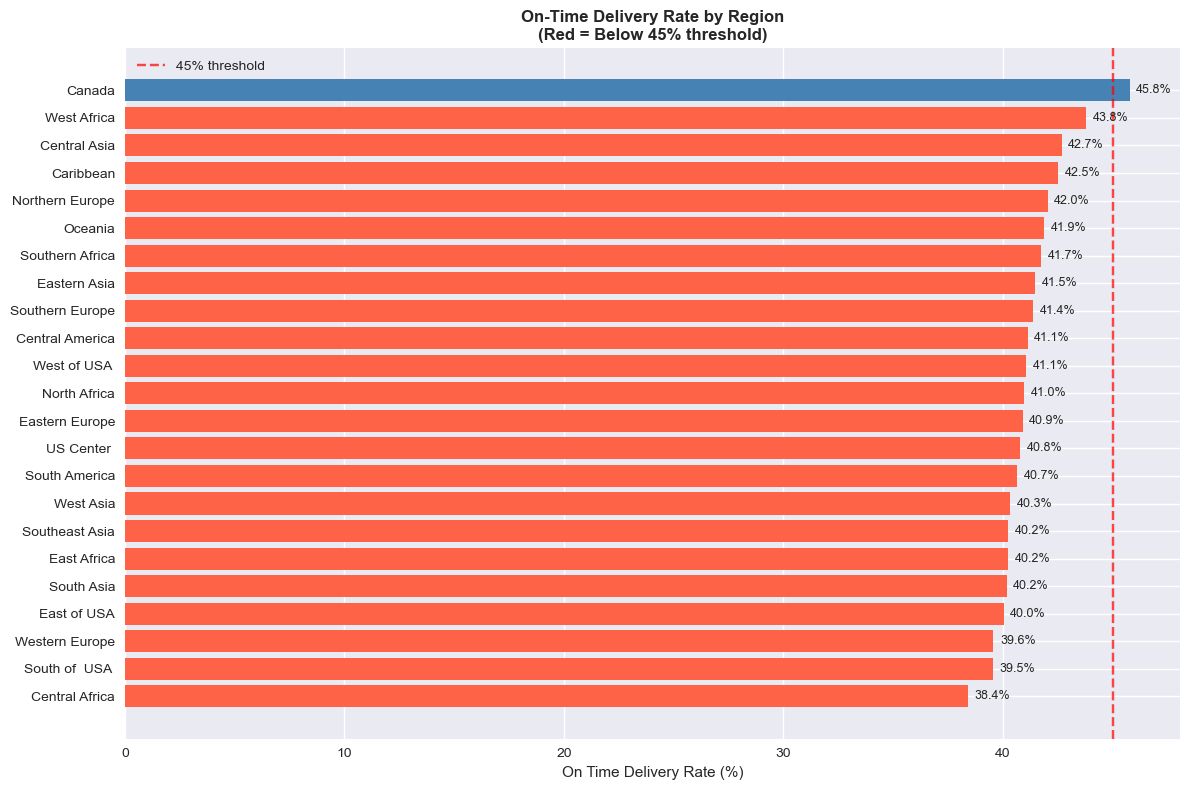

 Plot 2 saved


In [45]:
# ============================================================
# STEP 7B — EDA: DELAY RATE BY REGION
# Why: Surfaces regional bottlenecks — the core finding
#      we will highlight in the Power BI dashboard
# ============================================================

fig, ax = plt.subplots(figsize=(12, 8))

delay_by_region = df.groupby('order_region')['is_on_time'].mean().sort_values()

colors = ['tomato' if v < 0.45 else 'steelblue' for v in delay_by_region.values]
bars = ax.barh(delay_by_region.index, delay_by_region.values * 100, color=colors)

ax.set_xlabel('On Time Delivery Rate (%)')
ax.set_title('On-Time Delivery Rate by Region\n(Red = Below 45% threshold)', 
             fontweight='bold')
ax.axvline(x=45, color='red', linestyle='--', alpha=0.7, label='45% threshold')

for bar, val in zip(bars, delay_by_region.values):
    ax.text(val * 100 + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1%}', va='center', fontsize=9)

ax.legend()
plt.tight_layout()
plt.savefig(r'D:\AG\Supply chain project\plot2_delay_by_region.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(" Plot 2 saved")

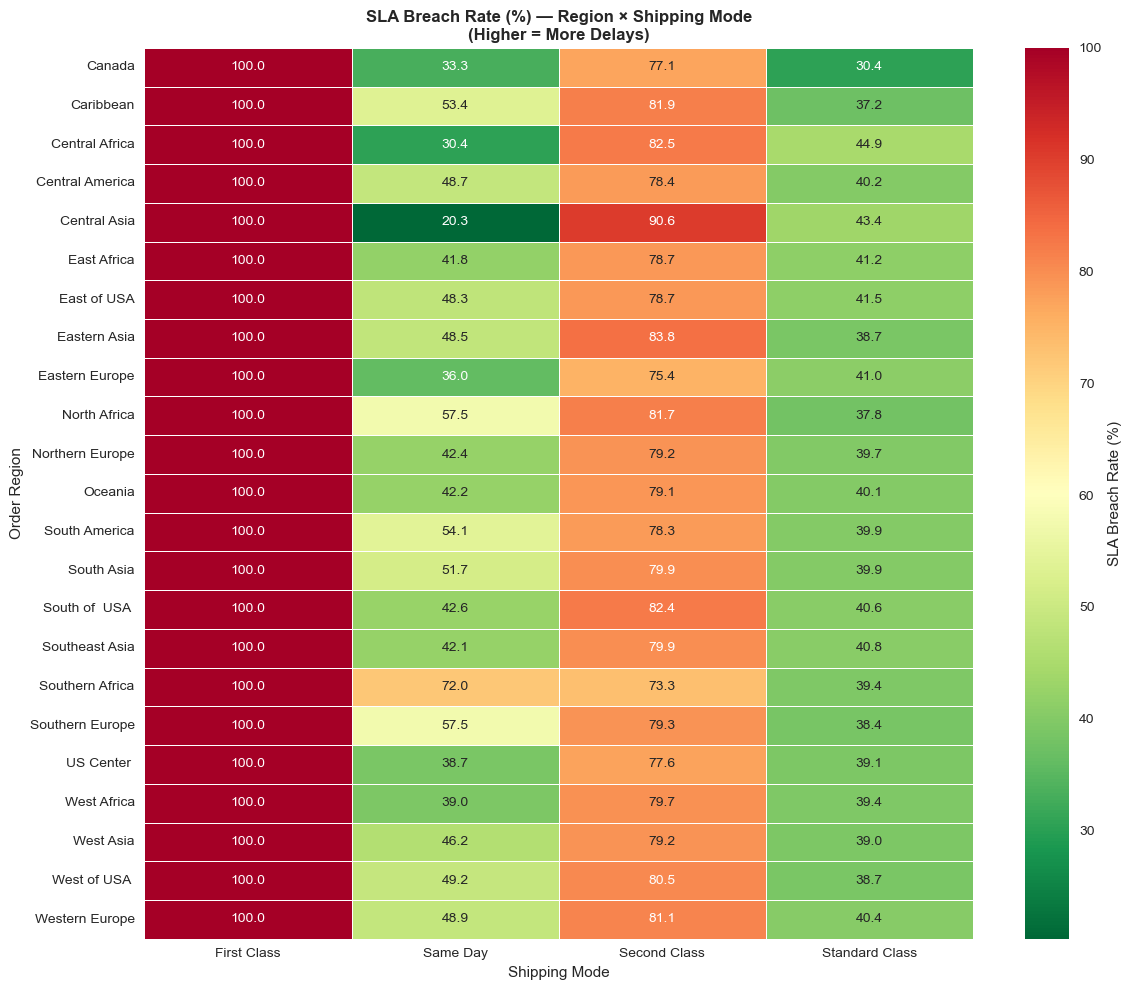

 Plot 3 saved


In [46]:
# ============================================================
# STEP 7C — EDA: SLA BREACH HEATMAP (Region x Shipping Mode)
# Why: This is the KEY cross-analysis that finds the hidden
#      15% delay story — which region+mode combo is worst?
# ============================================================

pivot_sla = df.pivot_table(
    values='is_sla_breach',
    index='order_region',
    columns='shipping_mode',
    aggfunc='mean'
) * 100

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    pivot_sla,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn_r',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'SLA Breach Rate (%)'}
)
ax.set_title('SLA Breach Rate (%) — Region × Shipping Mode\n(Higher = More Delays)', 
             fontweight='bold')
ax.set_xlabel('Shipping Mode')
ax.set_ylabel('Order Region')

plt.tight_layout()
plt.savefig(r'D:\AG\Supply chain project\plot3_sla_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(" Plot 3 saved")

In [47]:
# ============================================================
# STEP 8 — EXPORT CLEAN DATA FOR SQL IMPORT
# Why: SQL Server will import this clean CSV directly.
#      All column names are snake_case (no spaces = no errors)
#      All types are correct (dates, numerics, flags)
#      All KPI flags are pre-engineered
# ============================================================

CLEAN_PATH = r"D:\AG\Supply chain project\supplychain_clean.csv"

df.to_csv(CLEAN_PATH, index=False)

print(f" Clean data exported successfully")
print(f"\nFile saved to:")
print(f"  {CLEAN_PATH}")
print(f"\nFinal dataset summary:")
print(f"  Rows      : {df.shape[0]:,}")
print(f"  Columns   : {df.shape[1]}")
print(f"\nNew columns added:")
new_cols = ['order_year','order_month','order_quarter','order_dow',
            'is_full_year','is_on_time','is_complete','is_qty_fulfilled',
            'is_otif','is_sla_breach','days_variance','is_perfect_order']
for col in new_cols:
    print(f"  → {col}")

print(f"\n{'='*50}")
print("PHASE 2 COMPLETE — Ready for SQL Server import")
print(f"{'='*50}")

 Clean data exported successfully

File saved to:
  D:\AG\Supply chain project\supplychain_clean.csv

Final dataset summary:
  Rows      : 180,519
  Columns   : 37

New columns added:
  → order_year
  → order_month
  → order_quarter
  → order_dow
  → is_full_year
  → is_on_time
  → is_complete
  → is_qty_fulfilled
  → is_otif
  → is_sla_breach
  → days_variance
  → is_perfect_order

PHASE 2 COMPLETE — Ready for SQL Server import


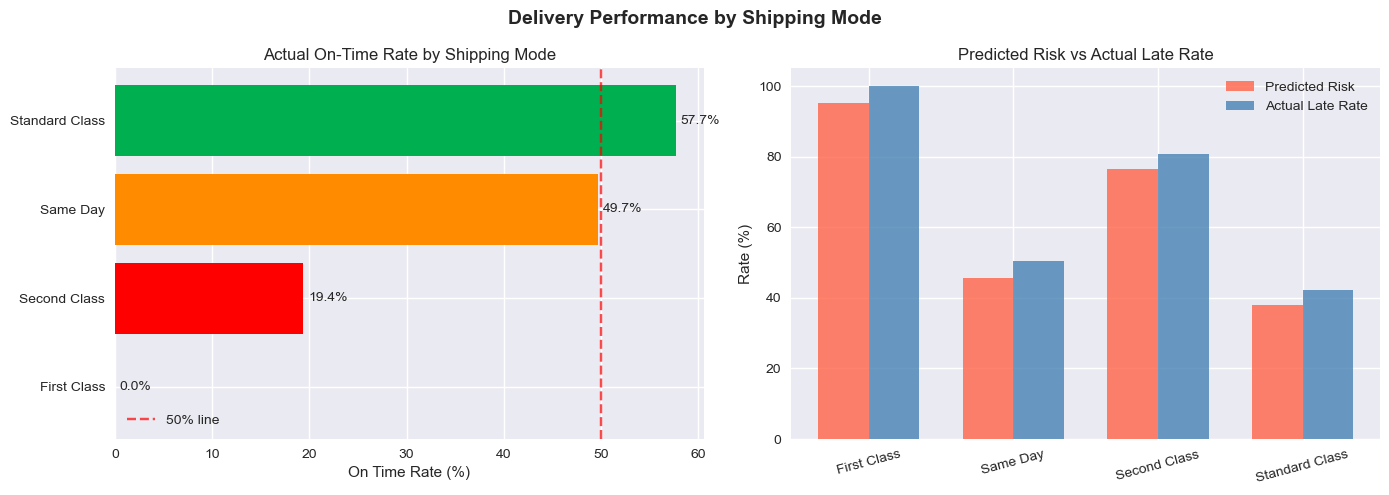

 Plot 1 saved to: D:\AG\Supply chain project\Python\plot1_delay_by_shipmode.png


In [59]:
# ============================================================
# REGENERATE PLOT 1 — Delay by Shipping Mode
# Saving to Python folder
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load clean data
df = pd.read_csv(r"D:\AG\Supply chain project\Python\supplychain_clean.csv")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Delivery Performance by Shipping Mode', 
             fontsize=14, fontweight='bold')

# Chart 1 — Actual on-time rate
delay_by_mode = df.groupby('shipping_mode')['is_on_time'].mean().sort_values()

colors1 = ['#FF0000' if v < 0.20 else '#FF8C00' if v < 0.50 else '#00B050' 
           for v in delay_by_mode.values]
axes[0].barh(delay_by_mode.index, delay_by_mode.values * 100, color=colors1)
axes[0].set_xlabel('On Time Rate (%)')
axes[0].set_title('Actual On-Time Rate by Shipping Mode')
axes[0].axvline(x=50, color='red', linestyle='--', alpha=0.7, label='50% line')
for i, (idx, val) in enumerate(delay_by_mode.items()):
    axes[0].text(val * 100 + 0.5, i, f'{val:.1%}', va='center')
axes[0].legend()

# Chart 2 — Predicted risk vs actual outcome
risk_compare = df.groupby('shipping_mode').agg(
    predicted_risk = ('late_delivery_risk', 'mean'),
    actual_late    = ('is_on_time', lambda x: 1 - x.mean())
).reset_index()

x = np.arange(len(risk_compare))
width = 0.35
axes[1].bar(x - width/2, risk_compare['predicted_risk'] * 100, 
            width, label='Predicted Risk', color='tomato', alpha=0.8)
axes[1].bar(x + width/2, risk_compare['actual_late'] * 100, 
            width, label='Actual Late Rate', color='steelblue', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(risk_compare['shipping_mode'], rotation=15)
axes[1].set_ylabel('Rate (%)')
axes[1].set_title('Predicted Risk vs Actual Late Rate')
axes[1].legend()

plt.tight_layout()

# Save to Python folder
SAVE_PATH = r"D:\AG\Supply chain project\Python\plot1_delay_by_shipmode.png"
plt.savefig(SAVE_PATH, dpi=150, bbox_inches='tight')
plt.show()

print(f" Plot 1 saved to: {SAVE_PATH}")